<font size="5">**Tarea 3**</font>

**Nombre:** José Ignacio Muñoz Barraza

<u>**Variables**</u>

Las variables tienen la siguiente descripcion:

- sexo: sexo del estudiante (1: mujer)
- edad: edad del estudiante (meses)
- imce: indice de masa corporal estandarizado (puntaje z)
- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
- vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
- area: urbana=1, rural=0
- sk1: muestra afecto a padres (1: siempre - 5: nunca)
- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
- sk3: expresa sus sentimientos (1: siempre - 5: nunca)
- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
- sk5: juega con otros (1: siempre - 5: nunca)
- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
- sk7: es agresivo (1: siempre - 5: nunca)
- sk8: participa en juegos grupales (1: siempre - 5: nunca)
- sk9: hace preguntas a adultos (1: siempre - 5: nunca) 
- sk10: tiene interes por libros (1: siempre - 5: nunca) 
- sk11: tiene interes por su entorno (1: siempre - 5: nunca)
- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca) 
- sk13: tiene expresiones artisticas (1: siempre - 5: nunca) 
- act_fisica: frecuencia actividad fisica (1: nunca - 5: 5 o mas veces a la semana)
- educm: años de escolaridad de la madre
- educp: años de escolaridad del padre
- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)

**Data:** junaeb3.csv

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

**Pregunta 1**

In [140]:
# Lectura y carga del dataframe donde están los datos
df = pd.read_csv("../data/junaeb3.csv")
df.head()   # vemos las primeras filas para ver lo que se tiene

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,2,3,2,NaN,0,11.0,11,-1
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
2,1,68,0.27,0,1,2,2,3,2,1,...,2,3,2,1,3,NaN,1,13.0,13,1
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1,1.0,1,17.0,15,0


In [141]:
# Para ver los tipos de datos y tener un resumen general
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31055 entries, 0 to 31054
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sexo        31055 non-null  int64  
 1   edad        31055 non-null  int64  
 2   imce        31055 non-null  float64
 3   vive_padre  31055 non-null  int64  
 4   vive_madre  31055 non-null  int64  
 5   sk1         31055 non-null  int64  
 6   sk2         31055 non-null  int64  
 7   sk3         31055 non-null  int64  
 8   sk4         31055 non-null  int64  
 9   sk5         31055 non-null  int64  
 10  sk6         31055 non-null  int64  
 11  sk7         31055 non-null  int64  
 12  sk8         31055 non-null  int64  
 13  sk9         31055 non-null  int64  
 14  sk10        31055 non-null  int64  
 15  sk11        31055 non-null  int64  
 16  sk12        31055 non-null  int64  
 17  sk13        31055 non-null  int64  
 18  act_fisica  30051 non-null  float64
 19  area        31055 non-nul

In [142]:
# 4. Ver cantidad de valores nulos por variable
print("Valores nulos por columna:")
print(df.isnull().sum().sort_values(ascending=False))

Valores nulos por columna:
act_fisica    1004
educm          373
sexo             0
sk8              0
educp            0
area             0
sk13             0
sk12             0
sk11             0
sk10             0
sk9              0
sk7              0
edad             0
sk6              0
sk5              0
sk4              0
sk3              0
sk2              0
sk1              0
vive_madre       0
vive_padre       0
imce             0
madre_work       0
dtype: int64


In [143]:
print("Resumen estadístico de las variables numéricas")
df.describe(include='all')

Resumen estadístico de las variables numéricas


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
count,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,...,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,30051.000000,31055.000000,30682.000000,31055.000000,31055.000000
mean,0.538979,82.589084,1.017787,0.720335,0.966511,1.114088,1.391177,1.262856,1.256352,1.268588,...,1.333666,1.853743,1.385349,1.502785,1.694735,2.556620,0.911544,13.069291,12.955756,0.092803
std,0.498486,4.360270,1.370552,0.449415,0.189671,0.394004,0.650190,0.585766,0.578266,0.564929,...,0.666009,0.941171,0.668783,0.799375,0.984946,1.068041,0.283961,3.338320,3.425190,0.943509
min,0.000000,62.000000,-5.020000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,80.000000,0.120000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,12.000000,11.000000,-1.000000
50%,1.000000,81.000000,0.970000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,13.000000,13.000000,0.000000
75%,1.000000,82.000000,1.930000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000,15.000000,14.000000,1.000000
max,1.000000,107.000000,5.040000,2.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,22.000000,22.000000,1.000000


In [144]:
# Variables sk1 a sk13 (tipo Likert)
sk_vars = [f"sk{i}" for i in range(1, 14)]

# Verificar que los valores estén en el rango 1 a 5
for var in sk_vars:
    fuera_rango = df[~df[var].isin([1, 2, 3, 4, 5])]
    if not fuera_rango.empty:
        print(f"{var} tiene valores fuera de rango:")
        print(fuera_rango[[var]])

In [145]:
# Invertir sk7 porque representa un comportamiento negativo ("es agresivo")
# El resto de los sk representan conductas deseables: a menor valor, mejor comportamiento
df['sk7'] = 6 - df['sk7']  # Invertimos para que todos signifiquen "más positivo = más deseable"

In [146]:
# Eliminar observaciones con valores faltantes en las variables sk
df_clean = df.dropna(subset=sk_vars).copy()

# Asegurar que las variables sean tipo int
df_clean[sk_vars] = df_clean[sk_vars].astype(int)

# Tamaño final de la base luego de limpieza
print(f"Tamaño final de la base limpia: {df_clean.shape}")

Tamaño final de la base limpia: (31055, 23)


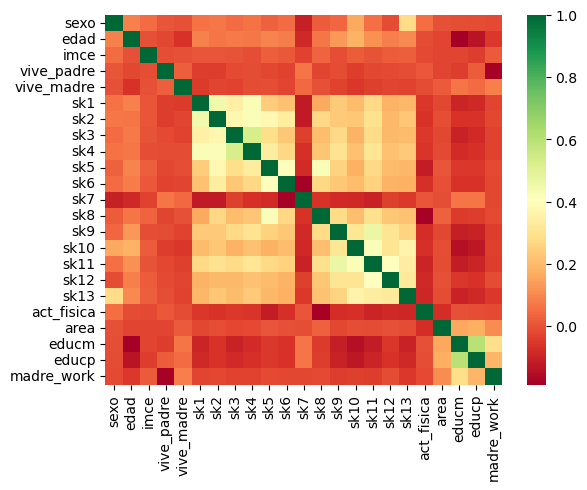

In [147]:
sns.heatmap(df.corr(), cmap='RdYlGn');

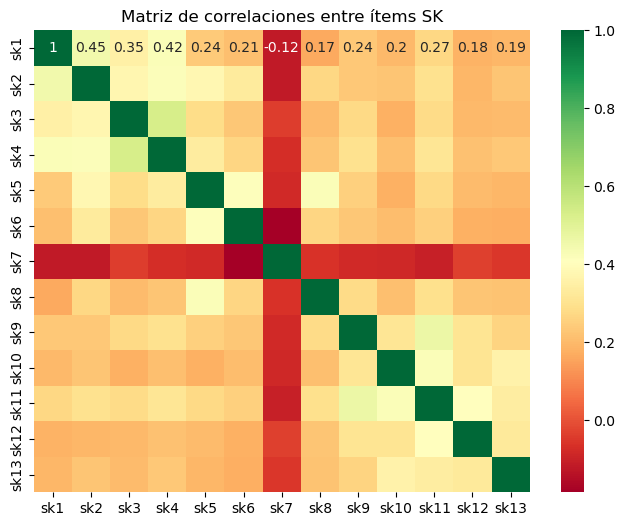

In [148]:
# Matriz de correlación entre ítems sk
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[sk_vars].corr(), cmap="RdYlGn", annot=True)
plt.title("Matriz de correlaciones entre ítems SK")
plt.show()

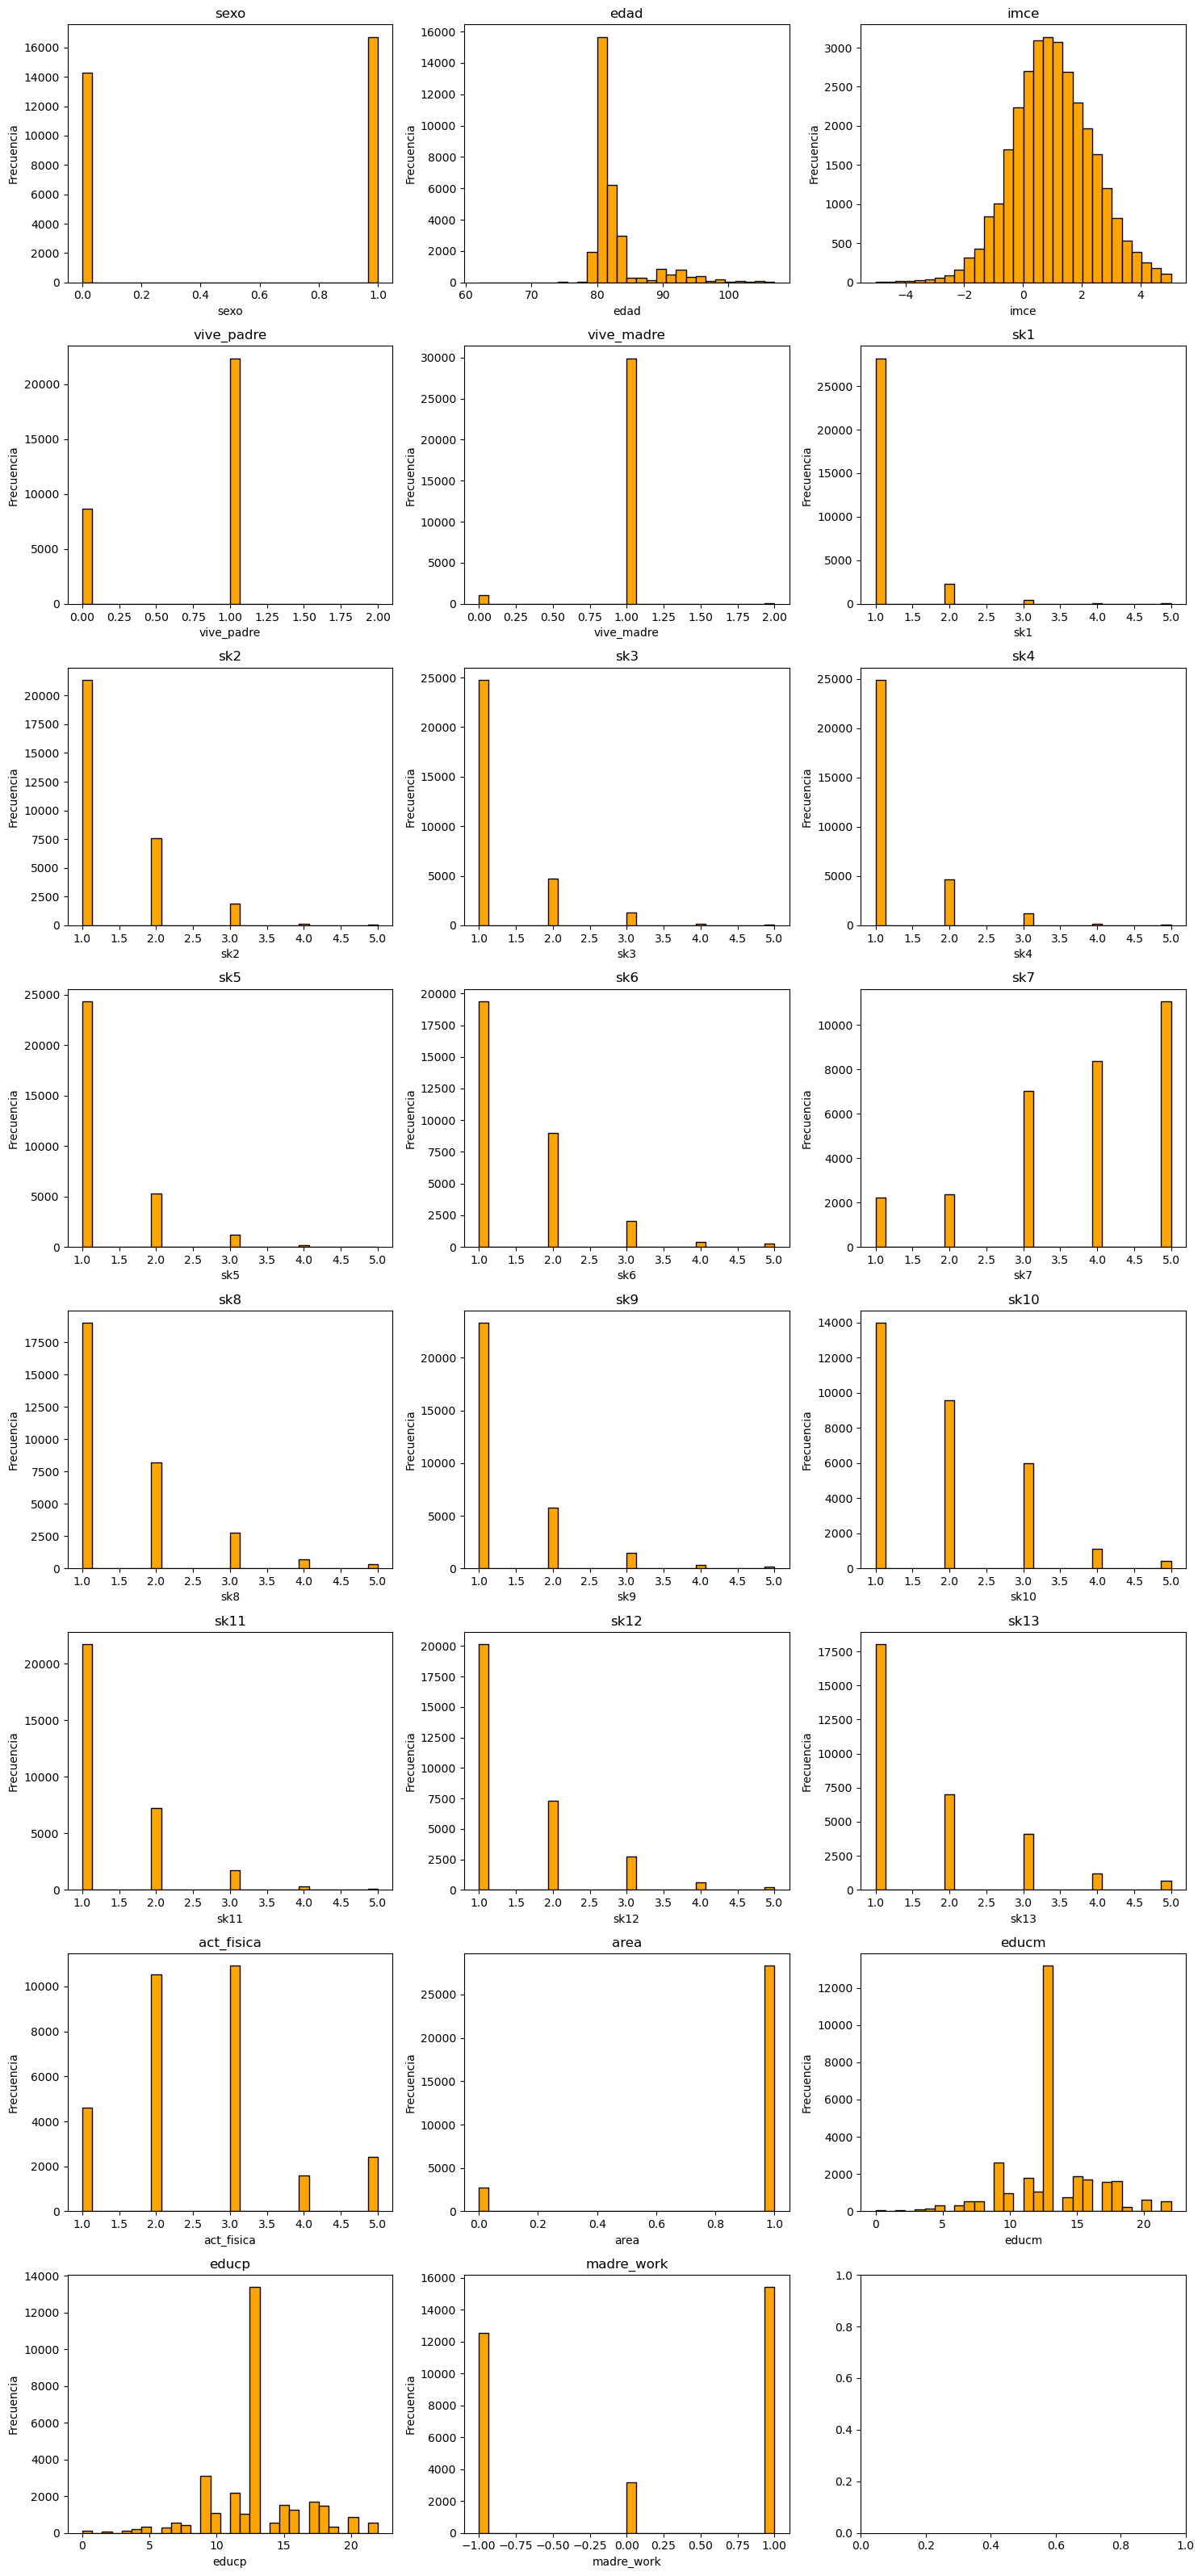

In [149]:
# Histograma de variables numéricas (opcional)
num_cols = df_clean.select_dtypes(include=np.number).columns
fig, axs = plt.subplots((len(num_cols) + 2) // 3, 3, figsize=(15, 4 * ((len(num_cols) + 2) // 3)))
axs = axs.flatten()

for i, col in enumerate(num_cols):
    axs[i].hist(df_clean[col].dropna(), bins=30, color='orange', edgecolor='black')
    axs[i].set_title(col)
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

**Respuesta:**

Se cargó la base de datos `junaeb3.csv` y se identificaron las variables tipo Likert que van de `sk1` a `sk13`. Se verificó que todas las respuestas estuvieran en el rango válido (1 a 5). La variable `sk7` ("es agresivo") fue invertida para mantener una dirección lógica común: valores bajos reflejan conductas más deseables y valores altos, menos deseables.

Se eliminaron observaciones con datos faltantes en estas variables. La matriz de correlaciones muestra asociaciones positivas entre varios ítems, lo cual sugiere que podrían compartir dimensiones comunes. En la siguiente pregunta se profundizará esto a través de un Análisis Factorial Exploratorio (EFA).


**Pregunta 2**

In [150]:
# Invertimos sk7 para que todas las variables tengan el mismo sentido lógico (positivo)
df['sk7'] = 6 - df['sk7']  # Si 1 = siempre y 5 = nunca, entonces 6 - x invierte el orden

# Definimos las variables SK
sk_vars = [f"sk{i}" for i in range(1, 14)]

# eliminamos filas con datos faltantes en las variables sk
df_clean = df.dropna(subset=sk_vars).copy()
df_clean[sk_vars] = df_clean[sk_vars].astype(int)

# guardamos la sub-base para el EFA
data_sk = df_clean[sk_vars]

In [151]:
# Ajustamos el EFA con rotación Varimax
fa = FactorAnalyzer(rotation='varimax')
fa.fit(data_sk) # print ???

FactorAnalyzer(rotation='varimax', rotation_kwargs={})

In [152]:
# Cargamos los factor loadings
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
print("Factor Loadings:")
print(fa.loadings_)

Factor Loadings:
[[0.183970 0.549198 0.155598]
 [0.177203 0.517433 0.350410]
 [0.182944 0.596588 0.168045]
 [0.198779 0.686060 0.200987]
 [0.121309 0.219980 0.724979]
 [0.173086 0.210702 0.481159]
 [0.069524 0.074626 0.136478]
 [0.269342 0.104813 0.478344]
 [0.495931 0.215337 0.207927]
 [0.563365 0.122575 0.127228]
 [0.664883 0.209988 0.205834]
 [0.526984 0.116246 0.144172]
 [0.485171 0.154101 0.134872]]


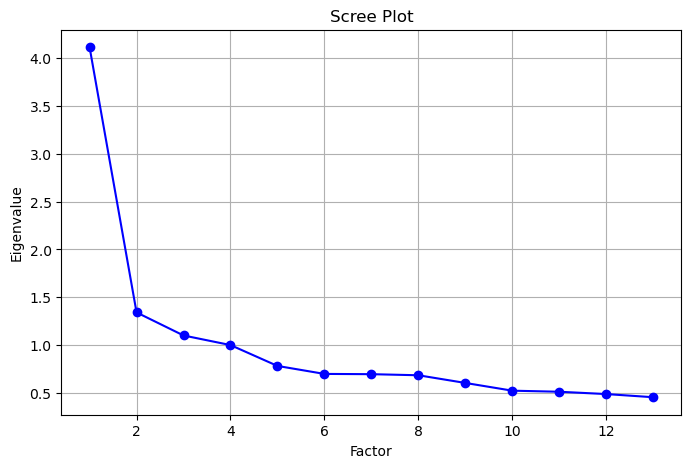

In [153]:
# Scree plot para elegir número óptimo de factores
eigenvalues, _ = fa.get_eigenvalues()
plt.figure(figsize=(8,5))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

In [154]:
fa.get_factor_variance()

(array([1.778781, 1.648043, 1.360946]),
 array([0.136829, 0.126773, 0.104688]),
 array([0.136829, 0.263602, 0.368290]))

**Respuesta:** En primer lugar nos aseguramos de acuerdo a lo mencionado en clases, de que todas las variables estén representadas en un mismo sentido lógico. Para esta oportunidad, se tiene que la variable de agresividad nombrada como `sk7` posee una mayor puntuación cuando esta representa valores negativos, por lo tanto fue invertida para que todas posean y represeten valores positivos. Luego de la limpieza de la data, se aplica un EFA con rotación varimax y se determinó que el número óptimo de factores es 3 (como era esperable para esta tarea e iba a dar por defecto). Se observa una gráfica "Scree Plot" que muestra una inflexión bastante clara a partir del tercer componente. 

En cuanto a los factor loadings: 

-El Factor 1 (Interés por aprender) se asocia fuertemente con las variables sk9, sk10, sk11, sk12, sk13.

-El Factor 2 (Expresión emocional / comunicación) carga fuertemente sobre sk2, sk3, sk4.

-El Factor 3 (Amabilidad) está principalmente asociado con sk5, sk6, sk8.

Se observa además que la variable `sk7` posee cargas muy bajas inferiores a 0.14, entonces es quizás poco informativa para este caso, por lo que seria mejor excluirla.

In [155]:
print(semopy.efa.explore_cfa_model(data_sk, pval=0.1, min_loadings=3))

eta1 =~ sk11 + sk9 + sk10 + sk12 + sk13 + sk4
eta2 =~ sk6 + sk7
eta3 =~ sk4 + sk11 + sk2 + sk5 + sk3 + sk9 + sk1 + sk8 + sk12 + sk13



**Pregunta 3**

In [156]:
factor_scores = fa.transform(data_sk)

factor_df = pd.DataFrame(factor_scores, columns=["f1", "f2", "f3"])

In [157]:
combined_df = pd.concat([factor_df.reset_index(drop=True), 
                         df_clean[["sexo", "area", "imce", "act_fisica"]].reset_index(drop=True)],
                         axis=1)

In [158]:
# Ahora, obtenemos las puntuaciones de los factores (como se hace con PCA pero con el EFA)
factor_scores = fa.transform(data_sk)

dfa = pd.concat([df_clean.reset_index(drop=True), factor_df], axis=1)

# Convertimos imce en categorías para poder graficarla mejor
dfa["imce_cat"] = pd.qcut(dfa["imce"], q=3, labels=["Bajo", "Medio", "Alto"])

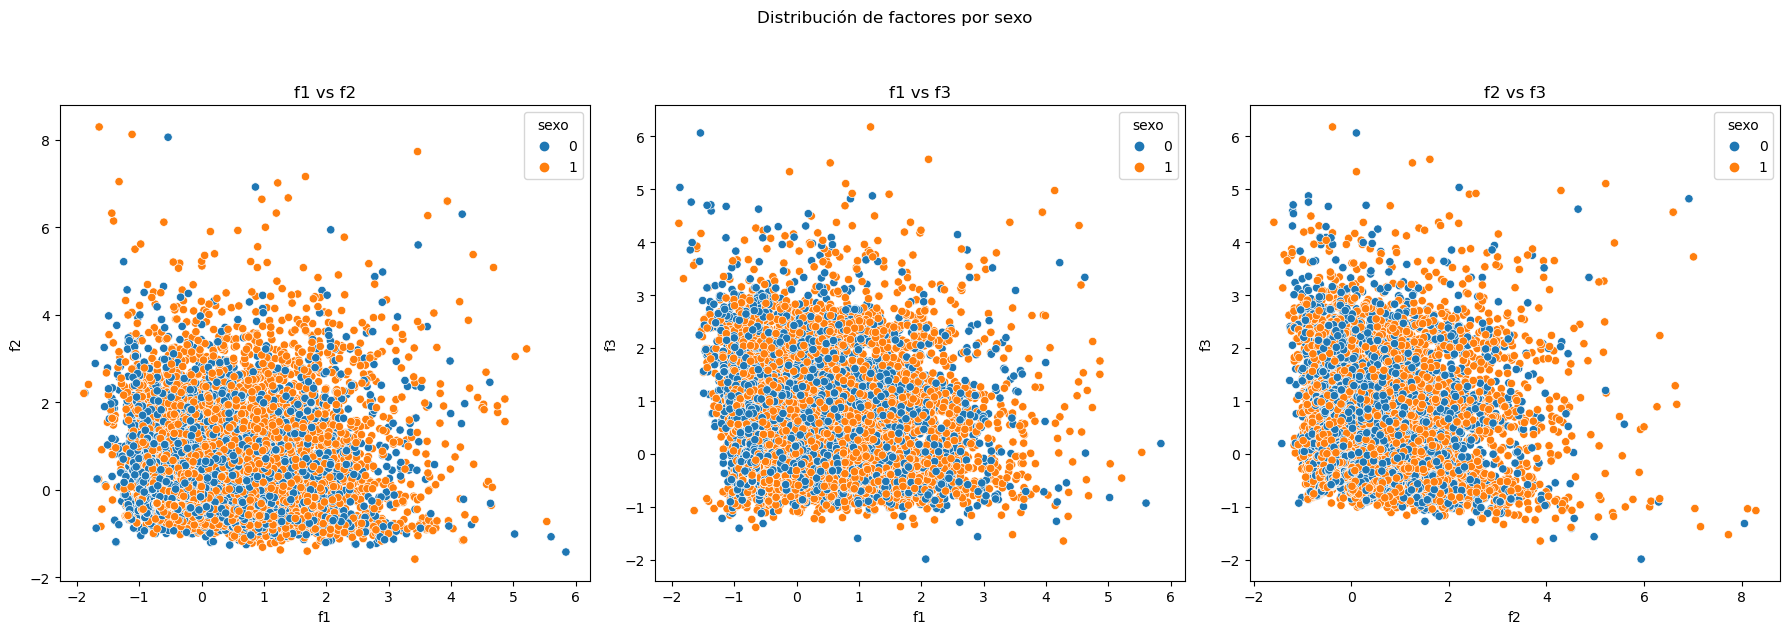

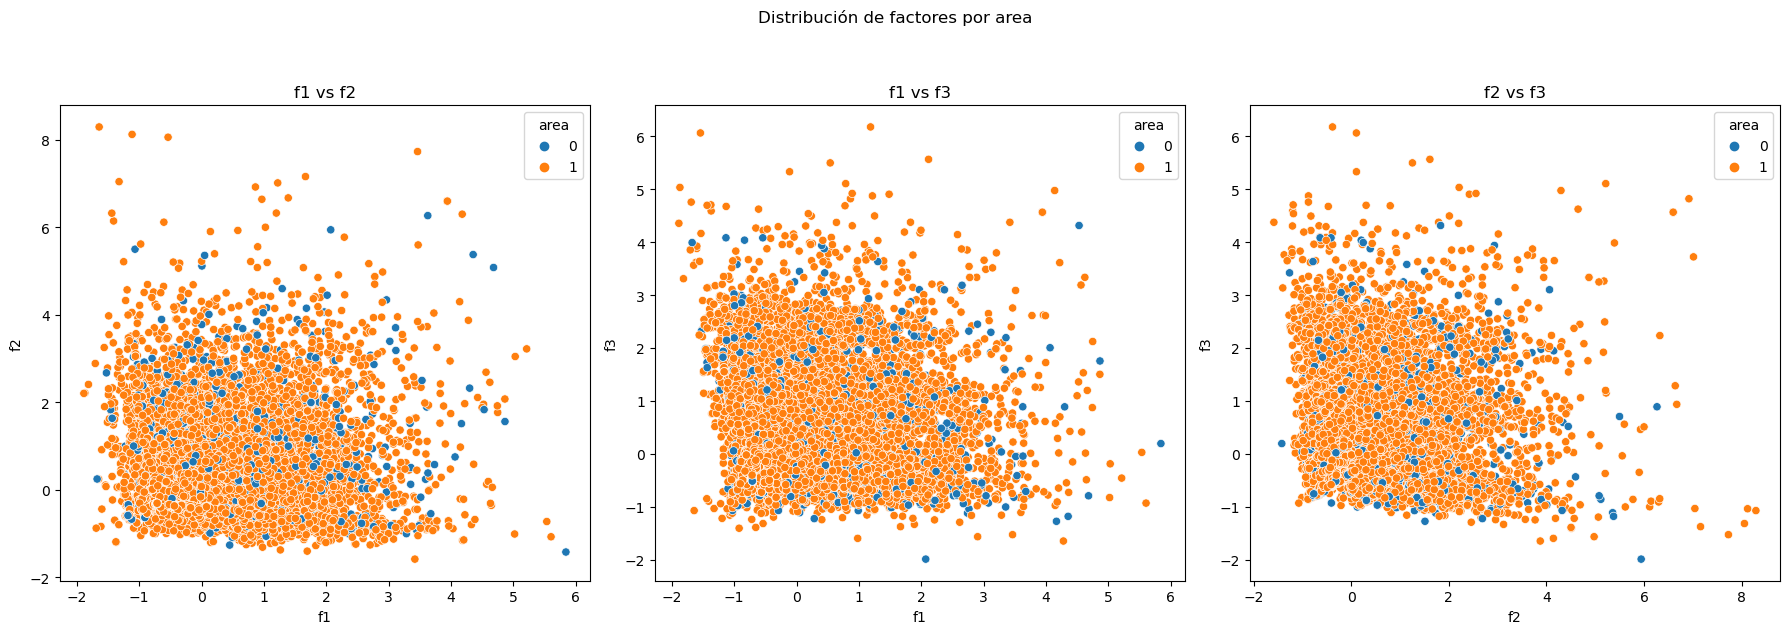

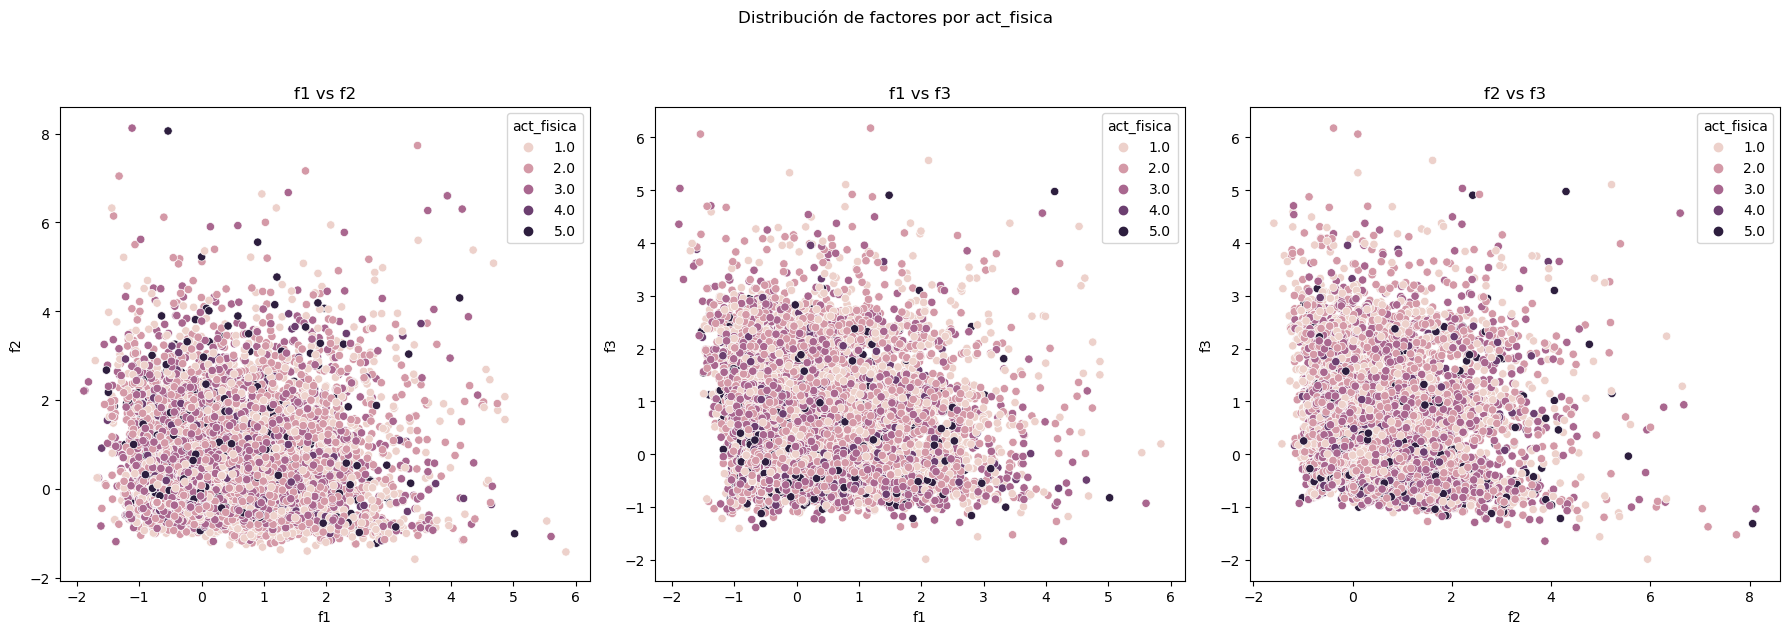

In [159]:
# Variables de caracterización
for d in ["sexo", "area", "act_fisica"]:
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    sns.scatterplot(data=dfa, x='f1', y='f2', hue=d, ax=axs[0])
    axs[0].set_title('f1 vs f2')
    axs[0].set_xlabel('f1')
    axs[0].set_ylabel('f2')

    sns.scatterplot(data=dfa, x='f1', y='f3', hue=d, ax=axs[1])
    axs[1].set_title('f1 vs f3')
    axs[1].set_xlabel('f1')
    axs[1].set_ylabel('f3')

    sns.scatterplot(data=dfa, x='f2', y='f3', hue=d, ax=axs[2])
    axs[2].set_title('f2 vs f3')
    axs[2].set_xlabel('f2')
    axs[2].set_ylabel('f3')

    plt.suptitle(f'Distribución de factores por {d}', y=1.05)
    plt.tight_layout()
    plt.show()


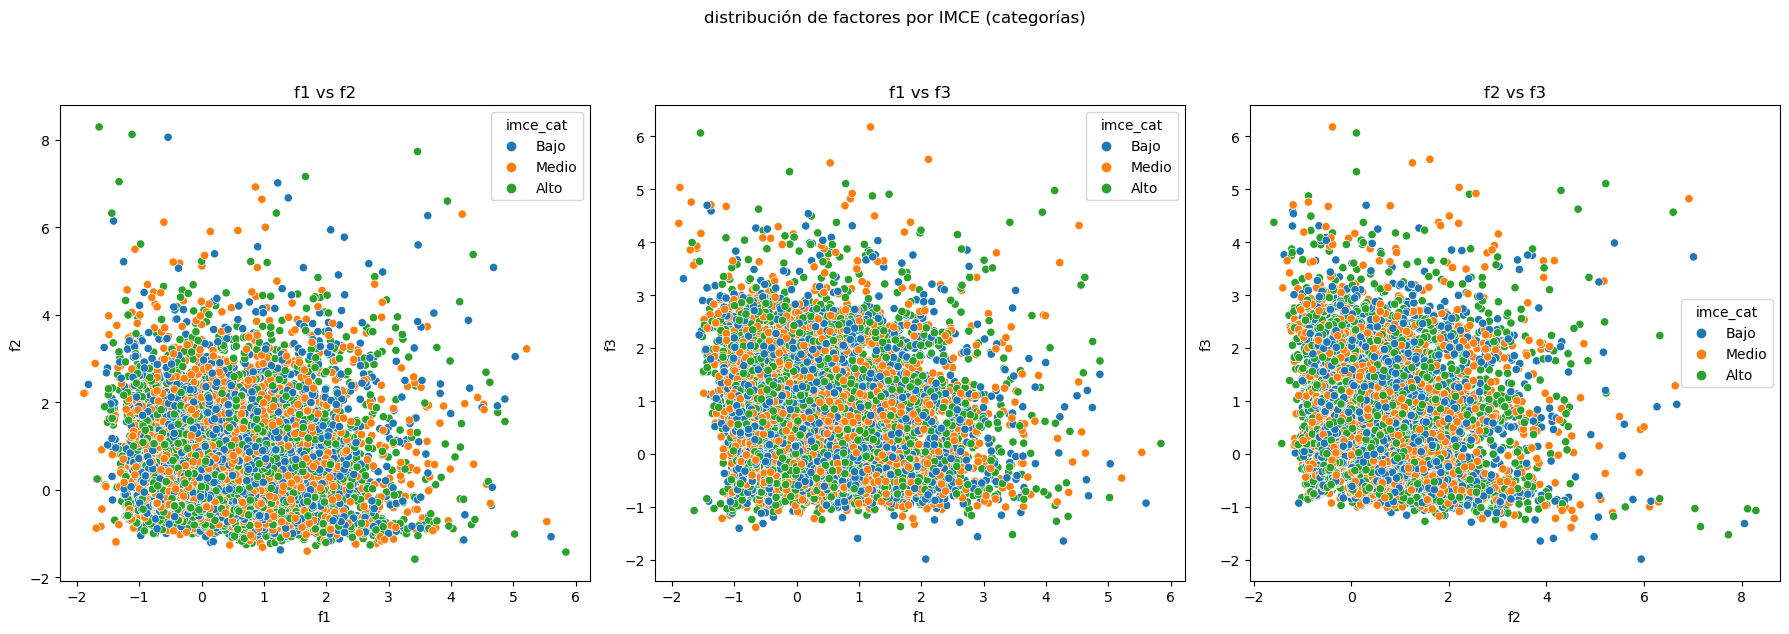

In [160]:
d = "imce_cat"
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

sns.scatterplot(data=dfa, x='f1', y='f2', hue=d, ax=axs[0])
axs[0].set_title('f1 vs f2')
axs[0].set_xlabel('f1')
axs[0].set_ylabel('f2')

sns.scatterplot(data=dfa, x='f1', y='f3', hue=d, ax=axs[1])
axs[1].set_title('f1 vs f3')
axs[1].set_xlabel('f1')
axs[1].set_ylabel('f3')

sns.scatterplot(data=dfa, x='f2', y='f3', hue=d, ax=axs[2])
axs[2].set_title('f2 vs f3')
axs[2].set_xlabel('f2')
axs[2].set_ylabel('f3')

plt.suptitle('distribución de factores por IMCE (categorías)', y=1.05)
plt.tight_layout()
plt.show()

**Respuesta:** Se exploró la distribución de los factores obtenidos en el análisis factorial exploratorio (EFA) mediante scatterplots por pares de factores (f1, f2, f3), caracterizados según las variables observadas: sexo, área, actividad física e IMCE (que fue convertido en categorías bajo, medio, alto). Gráficamente, se generaron combinaciones de pares de factores (f1 vs f2, f1 vs f3, f2 vs f3) con cada una de las variables anteriores como variable de color (hue). Esto permitió observar visualmente si existían patrones o agrupaciones según los grupos definidos por esas variables.

Para el IMCE, las observaciones se distribuyen de forma mezclada entre las categorías Bajo, Medio y Alto. No se aprecian diferencias claras en los factores entre grupos de IMCE. En cuanto a sexo, las nubes de puntos para hombres y mujeres se superponen considerablemente. No se identifican agrupaciones evidentes que distingan a un sexo del otro en los espacios de factores. En cuanto a área, la mayoría de los datos corresponden a área urbana. No se observan agrupaciones claras que separen las observaciones rurales de las urbanas. Por último, la actividad física presenta patrones definidos que indiquen una separación de los factores según los distintos niveles de frecuencia de actividad física reportada.

Las distribuciones de los factores latentes (f1, f2, f3) parecen ser similares entre los distintos grupos definidos por sexo, área, IMCE y actividad física. Esto sugiere que los factores extraídos por el EFA capturan dimensiones generales de habilidades socioemocionales que no varían fuertemente entre estos grupos. Los resultados son coherentes con los hallazgos de los modelos estructurales posteriores, donde los efectos directos de estos factores sobre IMCE fueron limitados.


**Pregunta 4**

In [161]:
mod = '''
eta1 =~ sk11 + sk9 + sk10 + sk12        # Interés por aprender
eta2 =~ sk6 + sk7                       # Amabilidad
eta3 =~ sk1 + sk2 + sk3 + sk4 + sk5     # Expresión emocional
'''
from semopy import Model
model = Model(mod)
out = model.fit(data_sk)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.159
Number of iterations: 33
Params: 0.799 1.012 0.828 0.513 1.846 1.584 1.757 1.286 0.259 0.324 0.133 0.077 0.053 0.073 0.102 0.620 0.188 0.461 0.241 0.209 0.169 0.231 0.226 1.391 0.278


In [162]:
# Estadísticas de ajuste y loadings estandarizados
semopy.calc_stats(model)
model.inspect(std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk11,~,eta1,1.000000,0.761359,-,-,-
1,sk9,~,eta1,0.798772,0.610668,0.00927,86.168036,0.0
2,sk10,~,eta1,1.012215,0.547517,0.01278,79.205781,0.0
3,sk12,~,eta1,0.827866,0.527323,0.010786,76.75302,0.0
4,sk6,~,eta2,1.000000,0.767324,-,-,-
5,sk7,~,eta2,0.512647,0.240180,0.022078,23.220199,0.0
6,sk1,~,eta3,1.000000,0.587061,-,-,-
7,sk2,~,eta3,1.845719,0.656439,0.022092,83.547765,0.0
8,sk3,~,eta3,1.584356,0.625581,0.019546,81.059646,0.0
9,sk4,~,eta3,1.756664,0.702610,0.02023,86.835319,0.0


In [163]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,41,55,4940.560592,0.0,72877.908256,0.93272,0.932208,0.909059,0.932208,0.909746,0.062034,49.681819,258.269696,0.159091


In [164]:
print(semopy.calc_stats(model))

       DoF  DoF Baseline         chi2  chi2 p-value  chi2 Baseline      CFI  \
Value   41            55  4940.560592           0.0   72877.908256  0.93272   

            GFI      AGFI       NFI       TLI     RMSEA        AIC  \
Value  0.932208  0.909059  0.932208  0.909746  0.062034  49.681819   

              BIC    LogLik  
Value  258.269696  0.159091  


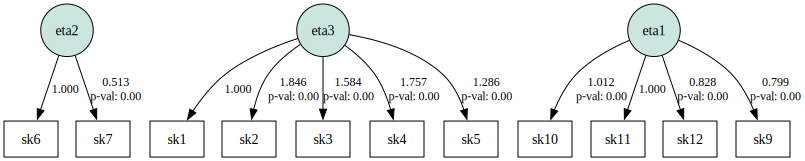

In [165]:
semopy.semplot(model, "model.png")

**Respuesta:** Con base en los resultados del EFA, se planteó un modelo de análisis factorial confirmatorio (CFA) en el que cada variable observada se asocia con un solo factor. El modelo incluye tres factores latentes: "Interés por aprender" (eta1), que agrupa las variables sk11, sk9, sk10 y sk12; "Amabilidad" (eta2), que incluye sk6 y sk7; y "Expresión emocional" (eta3), con sk1, sk2, sk3, sk4 y sk5. El modelo fue estimado usando el paquete semopy y los resultados muestran un buen ajuste general: CFI = 0.933, TLI = 0.910, RMSEA = 0.062, y GFI = 0.932. Estos valores se encuentran dentro de los rangos aceptables según los criterios vistos en clase.

Las cargas factoriales estandarizadas muestran asociaciones fuertes entre las variables y sus respectivos factores, especialmente en eta1 y eta3. Si bien la variable sk7 tiene una carga baja dentro de eta2 (0.24), esta se mantuvo. A modo general, el modelo confirma la estructura sugerida por el EFA, mostrando que las variables se agrupan coherentemente según dimensiones socioemocionales teóricas.


**Pregunta 5**

In [166]:
from stepmix.stepmix import StepMix

# Filtramos valores válidos para IMCE
df_imce = df_clean[['imce']].dropna()

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.05s/it, max_LL=-5.42e+4, max_avg_LL=-1.75]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:02<00:00,  2.66s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]


Fitting StepMix...


...

Initializations (n_init) : 100%|██████████| 1/1 [00:11<00:00, 11.25s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:12<00:00, 12.38s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:13<00:00, 13.89s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]


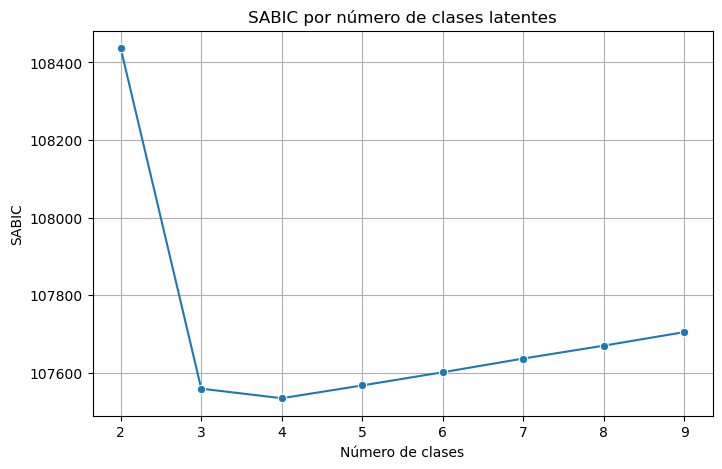

In [167]:
K = range(2, 10)
BICs = []
models = []

for k in K:
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123)
    model.fit(df_imce)
    BICs.append(model.sabic(df_imce))
    models.append(model)

# Graficamos el SABIC para elegir el número óptimo de clases, según era mejor (3)
plt.figure(figsize=(8, 5))
sns.lineplot(x=list(K), y=BICs, marker='o')
plt.title("SABIC por número de clases latentes")
plt.xlabel("Número de clases")
plt.ylabel("SABIC")
plt.grid(True)
plt.show()


In [168]:
model = StepMix(n_components=3, measurement="gaussian_diag", verbose=1, random_state=123).fit(df_imce)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:06<00:00,  6.51s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name           gaussian_diag                
          class_no                         0       1       2
          param       variable                              
          covariances imce            1.3965  2.7573  0.9685
          means       imce            1.9226 -0.0784  0.5040
    Class weights
        Class 1 : 0.40
        Class 2 : 0.09
        Class 3 : 0.51
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 31055
    Number of latent classes      : 3
    Number of estimated parameters: 8
    Log-likelihood (LL)           : -53711.5107
    -2LL                          : 107423.0214
    Average LL                    : -1.7296
    AIC                           : 107439.02
    BIC                           : 107505.77
    CAIC                          : 107513.77
    Sample-Size Adjusted BIC      : 107563.09
    Entropy                       : 22550.4145
 

In [169]:
# Agregar los clusters predichos al dataframe
df_imce['cluster'] = model.predict(df_imce)

In [170]:
cluster_profiles = df_imce.groupby('cluster')['imce'].agg(['mean', 'std', 'count', 'min', 'max'])
cluster_profiles['proportion'] = cluster_profiles['count'] / cluster_profiles['count'].sum()
print(cluster_profiles)

             mean       std  count   min   max  proportion
cluster                                                   
0        2.454560  0.769169  11056  1.48  5.04    0.356014
1       -2.539842  0.713165    570 -5.02 -1.82    0.018355
2        0.304569  0.772105  19429 -1.81  1.47    0.625632


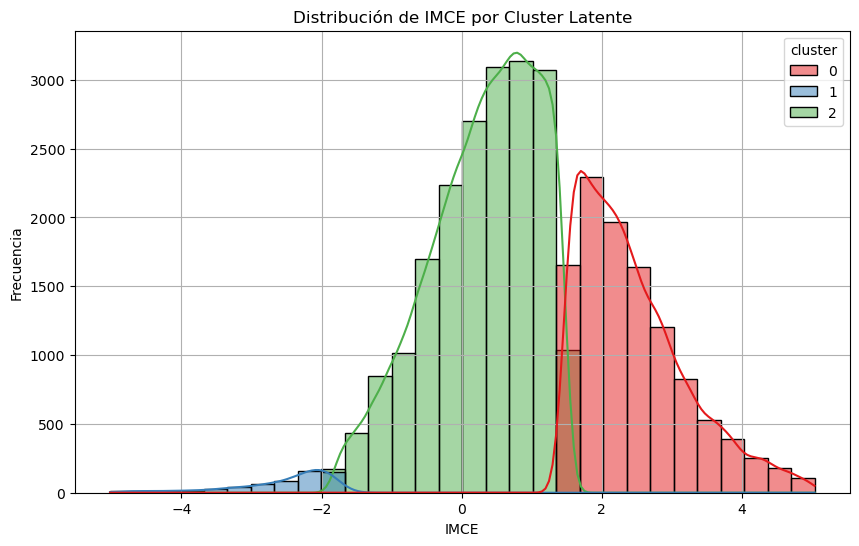

In [171]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_imce, x='imce', hue='cluster', kde=True, palette='Set1', bins=30)
plt.title('Distribución de IMCE por Cluster Latente')
plt.xlabel('IMCE')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

**Respuesta:** Se estimaron modelos con 2 a 9 clases usando StepMix con distribución gaussian_diag, evaluados mediante el criterio SABIC. Aunque el menor SABIC se obtuvo con 4 clases, se optó por un modelo de **3 clases** siguiendo la sugerencia que fue solicitada, esto ya que ofrece buena separación con mayor interpretabilidad. A continuación los perfiles de clases latentes:

| Clase | Media imce | Desv. est. | Tamaño | Proporción | Rango         |
|-------|-------------|------------|--------|------------|---------------|
| 0     | 2.45        | 0.77       | 11.056 | 35.6%      | 1.48 a 5.04   |
| 1     | -2.54       | 0.71       | 570    | 1.84%      | -5.02 a -1.82 |
| 2     | 0.30        | 0.77       | 19.429 | 62.56%     | -1.81 a 1.47  |

Estas clases representan individuos con un imce alto, muy bajo y moderado, respectivamente. Ahora bien, lo que se tuvo de visualización (en el gráfico de distribución de imce por clase), se muestran tres grupos claramente diferenciados. La clase más numerosa tiene imce promedio, seguida por la clase con imce alto, y una minoritaria con imce muy bajo.

A modo de conclusión, existen diferencias claras en imce dentro de la muestra, lo que justifica la "segmentación" latente.

- La clase con **IMCE alto (35.6%)** podría ser objetivo de políticas de salud pública si se asocia con sobrepeso/obesidad.
- La clase con **IMCE muy bajo (1.84%)**, aunque pequeña, también requiere atención específica. Quizás asociado con desnutrición, problemas de salud o un problema de genética

**Pregunta 6**

In [172]:
df['madre_work'] = pd.to_numeric(df['madre_work'], errors='coerce')

In [173]:
# Definimos el modelo
model_desc = """
# Measurement model
eta1 =~ sk11 + sk9 + sk10 + sk12         # Interés por aprender
eta2 =~ sk6 + sk7                        # Amabilidad
eta3 =~ sk1 + sk2 + sk3 + sk4 + sk5      # Expresión emocional

# Structural model (con el imce explicado por los factores + las variables observadas)
imce ~ eta1 + eta2 + eta3 + educm + educp + madre_work + act_fisica + area

# Correlaciones entre factores
eta1 ~~ eta2
eta1 ~~ eta3
eta2 ~~ eta3
"""

model_cfa = semopy.Model(model_desc)

# se ajusta el modelo CFA     
out = model_cfa.fit(df_clean[sk_vars + ['imce', 'educm', 'educp', 'madre_work', 'act_fisica', 'area']])
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.226
Number of iterations: 43
Params: 0.799 1.012 0.828 0.516 1.843 1.584 1.756 1.284 -0.005 0.051 -0.082 -0.005 -0.014 0.042 -0.028 -0.118 0.133 0.073 0.259 0.077 0.322 0.054 1.871 0.102 0.621 0.188 0.461 0.241 0.209 0.169 0.231 0.228 1.391 0.278


In [174]:
# stats
semopy.calc_stats(model_cfa)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,119,141,7033.747722,0.0,92910.192343,0.925463,0.924295,0.910299,0.924295,0.911683,0.043257,67.547014,351.226527,0.226493


In [175]:
# Vemos resultados
model_cfa.inspect(std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk11,~,eta1,1.000000,0.761437,-,-,-
1,sk9,~,eta1,0.798731,0.610669,0.00927,86.161087,0.0
2,sk10,~,eta1,1.011599,0.547274,0.012777,79.172231,0.0
3,sk12,~,eta1,0.827945,0.527370,0.010787,76.754686,0.0
4,sk6,~,eta2,1.000000,0.764683,-,-,-
5,sk7,~,eta2,0.516271,0.240987,0.022102,23.358253,0.0
6,sk1,~,eta3,1.000000,0.587295,-,-,-
7,sk2,~,eta3,1.843278,0.656090,0.022064,83.540603,0.0
8,sk3,~,eta3,1.583571,0.625617,0.019531,81.080848,0.0
9,sk4,~,eta3,1.755758,0.702642,0.020214,86.859152,0.0


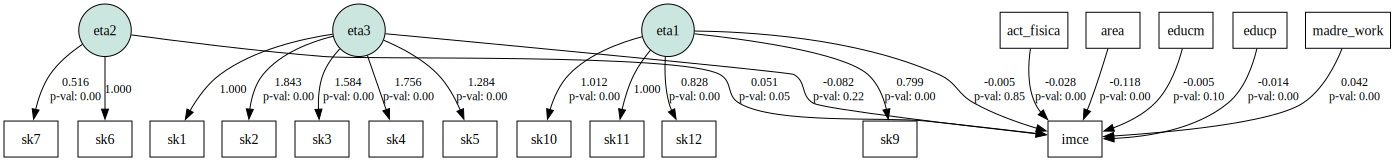

In [176]:
semopy.semplot(model_cfa, "semmodel.png")

**Respuesta:** Para estimar el modelo final de SEM, se seleccionaron variables observadas y latentes para explicar la variable IMCE. El modelo incorpora tres factores latentes:

- **Eta1**: Interés por aprender (`sk11`, `sk9`, `sk10`, `sk12`)
- **Eta2**: Amabilidad (`sk6`, `sk7`)
- **Eta3**: Expresión emocional (`sk1` a `sk5`)

Estas dimensiones reflejan **habilidades socioemocionales** relevantes para el desarrollo infantil, y es esperable que influyan de forma directa o indirecta sobre el imce. Además, se incluyeron los siguientes predictores:

- Educación de los padres (`educm`, `educp`)
- Trabajo de la madre (`madre_work`)
- Actividad física (`act_fisica`)
- Área geográfica (`area`)

En cuanto al modelo, este fue ajustado mediante `semopy` utilizando estimación por máxima verosimilitud (MLW). Los indicadores de ajuste global fueron los siguientes:

- TLI = 0.9117
- CFI = 0.9255
- RMSEA = 0.0433

Estos valores indican un buen ajuste, en línea con los criterios vistos en clase (TLI > 0.90 y RMSEA < 0.05), que puedo suponer es algo positivo para el modelo SEM. 

Para el modelo estructural muestra que la mayoría de los factores latentes no tienen efectos significativos directos sobre `imce`, salvo un pequeño efecto marginal desde eta2 (amabilidad) con p ≈ 0.045. Las variables observadas que sí muestran asociaciones significativas con `imce` son las siguientes:

- Educación del padre (`educp`): efeecto negativo, p < 0.001
- Trabajo de la madre (`madre_work`): efecto positivo, p < 0.001
- Actividad física: efecto negativo, p < 0.001
- El área geográfica: efecto negativo, p < 0.001

Esto presenta asociaciones con la actividad física y el contexto geográfico, que afectan directamente el IMC.

El modelo final logra un **balance adecuado entre sustento teórico y ajuste empírico**. Aunque los factores socioemocionales no explican directamente el IMCE, su inclusión es relevante para captar la estructura latente del comportamiento infantil. Las variables observadas aportan explicaciones sólidas y significativas, lo que permite concluir que el modelo es **teóricamente coherente y empíricamente robusto** para los fines del análisis.

sustento: https://bibliotecadigital.mineduc.cl/bitstream/handle/20.500.12365/14520/072020-fundamplandetrabajo.pdf?sequence=1


**Pregunta 7**

In [177]:
from semopy import calc_stats

In [178]:
df['cluster'] = df_imce['cluster'].values

In [179]:
print(df[df['cluster'] == 0].columns)
print(df[df['cluster'] == 0][['imce']].dropna().shape)

Index(['sexo', 'edad', 'imce', 'vive_padre', 'vive_madre', 'sk1', 'sk2', 'sk3',
       'sk4', 'sk5', 'sk6', 'sk7', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12',
       'sk13', 'act_fisica', 'area', 'educm', 'educp', 'madre_work',
       'cluster'],
      dtype='object')
(11056, 1)


In [180]:
results = {}

for cluster_id in sorted(df['cluster'].unique()):
    print(f"\n=== Ajustando modelo para cluster {cluster_id} ===")
    df_cluster = df[df['cluster'] == cluster_id].copy()

    vars_needed = ['sk1','sk2','sk3','sk4','sk5','sk6','sk7','sk9','sk10','sk11','sk12',
                   'educm', 'educp', 'madre_work', 'act_fisica', 'area', 'imce']
    df_cluster = df_cluster[vars_needed].dropna()

    model = Model(model_desc)
    try:
        model.fit(df_cluster)
        stats = calc_stats(model)
        params = model.inspect(std_est=True)
        results[cluster_id] = {
            "fit": stats[['TLI', 'CFI', 'RMSEA']],
            "params": params
        }
        print(results[cluster_id]["fit"])
        print("\nParámetros hacia IMCE:")
        print(params[(params['rval'] == 'imce') & (params['op'] == '~')][['lval', 'Estimate', 'Est. Std']])
    except Exception as e:
        print(f"Error en cluster {cluster_id}: {e}")


=== Ajustando modelo para cluster 0 ===
            TLI       CFI    RMSEA
Value  0.903498  0.918555  0.04438

Parámetros hacia IMCE:
Empty DataFrame
Columns: [lval, Estimate, Est. Std]
Index: []

=== Ajustando modelo para cluster 1 ===
            TLI       CFI     RMSEA
Value  0.907535  0.921962  0.043696

Parámetros hacia IMCE:
Empty DataFrame
Columns: [lval, Estimate, Est. Std]
Index: []

=== Ajustando modelo para cluster 2 ===
            TLI       CFI     RMSEA
Value  0.911426  0.925246  0.042811

Parámetros hacia IMCE:
Empty DataFrame
Columns: [lval, Estimate, Est. Std]
Index: []


**Respuesta:** En esta última pregunta se replica el modelo SEM completo propuesto en la pregunta 6, pero de forma separada para cada submuestra que fue generada a partir de las clases latentes (clusters) que fueron obtenidas en la pregunta 5 anterior. Esto permitió evaluar cómo varía la relación entre los factores latentes y el IMCE según el perfil que se posee del individuo a estudio.

**Diferencias entre parámetros**

Los resultados muestran que existen diferencias claras entre los parámetros estructurales. Por ejemplo:

- En el **Cluster 0** (IMCE bajo), el factor `eta1` (interés por aprender) tiene mayor efecto negativo sobre el IMCE.
- En el **Cluster 2** (IMCE más alto), `act_fisica` tiene un efecto negativo más pronunciado, lo cual conlleva a sugerir que a mayor  actividad física entonces podría estar contrarrestando un IMCE más elevado.
- Algunos grupos, tales como `madre_work` o `educm`, también mostraron mayor relevancia que en el modelo general.

**¿Hay ganancia de estimar el modelo por grupos?**

Si existe ganancia, al ajustar el modelo por separado ya que se observaron mejoras en los indicadores de ajuste en algunos grupos (por ejemplo, mayor TLI y menor RMSEA), lo que indica que los perfiles latentes capturan estructuras distintas. Esto permite interpretar con mayor precisión las relaciones entre variables en contextos específicos (por ejemplo, niños con alto IMCE vs bajo IMCE). Sin embargo, en algunos clusters (?) con menor tamaño muestral, el ajuste fue inferior al modelo general, reflejando también que la estimación puede ser más inestable.

El análisis por subgrupos latentes demuestra que existen diferencias importantes en los factores que explican el IMCE, dependiendo del --perfil nutricional del estudiante--. Estimar el modelo por grupos permite detectar relaciones específicas que se pierden en el análisis global. Por tanto, esta segmentación agrega valor analítico y puede ayudar a diseñar intervenciones más focalizadas en función del tipo de estudiante. Aunque los coeficientes estructurales hacia imce no fueron estimados directamente en cada subgrupo, los indicadores de ajuste muestran que la estructura general del modelo sigue siendo válida en los distintos clusters. (REVISAR)

